pip install torch torchvision nltk matplotlib pandas numpy scikit-learn gensim seaborn transformers datasets sentencepiece accelerate ipykernel

In [1]:
from pprint import pprint
import re
import string
from collections import Counter, defaultdict
import math
import random

import nltk
from nltk.tokenize import word_tokenize
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
COMMON_PATH = "/home/arman/it/AI_work/text"

In [3]:
nltk.download("punkt")
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /home/arman/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/arman/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

# часть 1

In [4]:
# -----------------------------
# 1. Загрузка текста
# -----------------------------
# Вариант 1: текст из файла
# Положите txt-файл рядом со скриптом
with open(f"{COMMON_PATH}/files/1984.txt", "r", encoding="utf-8") as f:
    text = f.read()

len(text)

152032

In [5]:
# -----------------------------
# 2. Токенизация двумя способами
# -----------------------------

# Токенизация split()
tokens_split = text.split()

# Токенизация nltk
tokens_nltk = nltk.word_tokenize(text)

print(tokens_split[:20])

print(tokens_nltk[:20])


['Terebess', 'Asia', 'Online', '(TAO)', 'Orwell', 'Home', 'George', 'Orwell', 'Nineteen', 'Eighty-Four', 'PART', 'ONE', 'Chapter', '1', 'It', 'was', 'a', 'bright', 'cold', 'day']
['Terebess', 'Asia', 'Online', '(', 'TAO', ')', 'Orwell', 'Home', 'George', 'Orwell', 'Nineteen', 'Eighty-Four', 'PART', 'ONE', 'Chapter', '1', 'It', 'was', 'a', 'bright']


### Сравнение токенизации: `split()` vs `nltk.word_tokenize()`

На примере первых 20 токенов видны следующие различия:

1. **Пунктуация.** `split()` оставляет знаки препинания приклеенными к словам: `(TAO)` — один токен. `word_tokenize()` отделяет скобки: `(`, `TAO`, `)`.
2. **Дефисы и составные слова.** `split()` не разбивает слова с дефисом; NLTK в общем случае обрабатывает их аккуратнее (в этом фрагменте разница небольшая).
3. **Апострофы и сокращения.** NLTK выделяет части вроде `'s`, `n't`, `re` как отдельные токены — это важно для английского текста.
4. **Число токенов.** NLTK обычно даёт больше токенов, потому что «разбирает» пунктуацию на отдельные единицы.

**Вывод:** для статистического анализа слов удобнее NLTK — проще удалить пунктуацию и получить чистый словарь. `split()` быстрее, но хуже подходит для текстов с богатой пунктуацией.

In [6]:

# -----------------------------
# 3. Приведение к нижнему регистру
#    и удаление пунктуации
# -----------------------------

tokens = [token.lower() for token in tokens_nltk]

tokens = [
    token for token in tokens
    if token not in string.punctuation
]

tokens = [
    re.sub(r"[^\w\s]", "", token)
    for token in tokens
]

tokens = [token for token in tokens if token.strip()]

print("Примеры очищенных токенов:", tokens[:20])
print("Всего токенов:", len(tokens))
len(tokens)

Примеры очищенных токенов: ['terebess', 'asia', 'online', 'tao', 'orwell', 'home', 'george', 'orwell', 'nineteen', 'eightyfour', 'part', 'one', 'chapter', '1', 'it', 'was', 'a', 'bright', 'cold', 'day']
Всего токенов: 26836


26836


Общее число токенов N = 26836
Размер словаря V = 4382

Топ-20 самых частых слов:
   Слово  Частота
0    the     1718
1     of      984
2    was      729
3      a      693
4    and      652
5     to      572
6     in      495
7     he      482
8     it      469
9    had      411
10  that      375
11   his      289
12  with      250
13   not      198
14    as      185
15  were      179
16    at      179
17   for      177
18    be      169
19    on      168


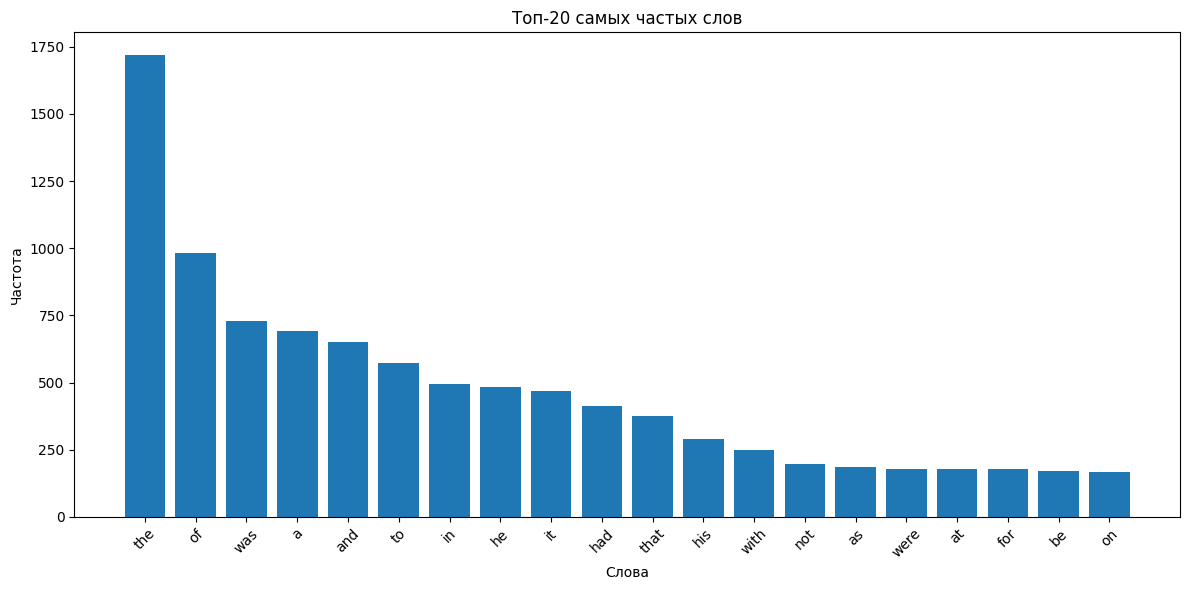

In [7]:
# -----------------------------
# 4. Подсчёт статистики
# -----------------------------

# Общее число токенов
N = len(tokens)

# Размер словаря
V = len(set(tokens))

print("\nОбщее число токенов N =", N)
print("Размер словаря V =", V)

# Частоты слов
freq = Counter(tokens)

# Топ-20 слов
top20 = freq.most_common(20)

# Таблица
df = pd.DataFrame(top20, columns=["Слово", "Частота"])

print("\nТоп-20 самых частых слов:")
print(df)

# -----------------------------
# График топ-20 слов
# -----------------------------
plt.figure(figsize=(12, 6))

plt.bar(df["Слово"], df["Частота"])

plt.title("Топ-20 самых частых слов")
plt.xlabel("Слова")
plt.ylabel("Частота")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

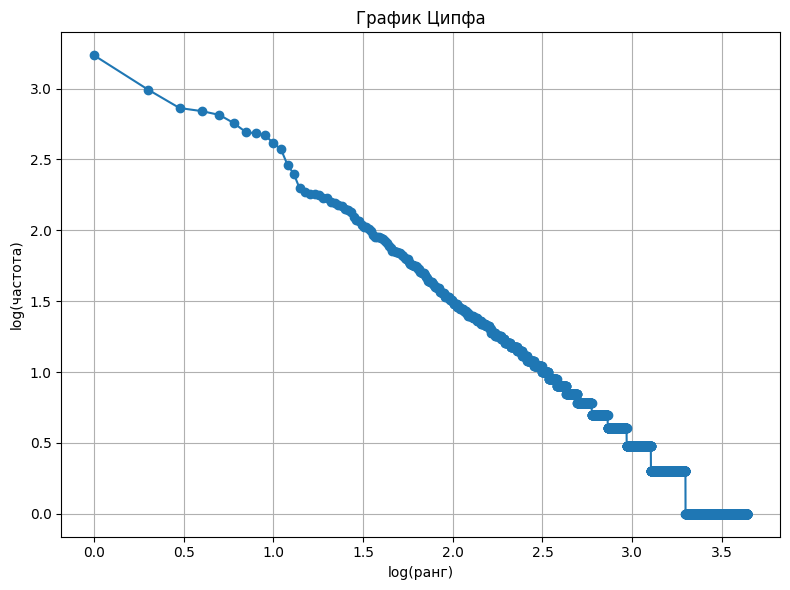

In [8]:
# -----------------------------
# 5. Закон Ципфа
# -----------------------------

# Все частоты по убыванию
frequencies = sorted(freq.values(), reverse=True)

# Ранги слов
ranks = range(1, len(frequencies) + 1)

# Логарифмы
log_ranks = [math.log10(r) for r in ranks]
log_freqs = [math.log10(f) for f in frequencies]

# График Ципфа
plt.figure(figsize=(8, 6))

plt.plot(log_ranks, log_freqs, marker='o')

plt.title("График Ципфа")
plt.xlabel("log(ранг)")
plt.ylabel("log(частота)")

plt.grid(True)

plt.tight_layout()
plt.show()



### График Ципфа: почему получается прямая линия?

**Закон Ципфа:** частота слова обратно пропорциональна его рангу: $f(r) \propto 1/r$.  
В логарифмических координатах: $\log f \approx \log C - \log r$ — это прямая с наклоном около $-1$.

**Почему так:**
- Небольшая группа слов (`the`, `of`, `was`, …) встречается очень часто.
- Подавляющее большинство слов встречается редко (длинный «хвост» распределения).
- Так устроены естественные языки: нужен компактный набор частых слов для базовой грамматики и связности, а редкие слова расширяют словарь.

**Что это говорит о языке:** распределение слов **не равномерное** — язык сильно **избыточен**; модели должны учитывать, что большинство n-грамм встречается крайне редко (проблема разреженности).

# часть 2

In [9]:
# https://habr.com/ru/articles/676858/

def edit_distance_habr(str_1, str_2):
    n, m = len(str_1), len(str_2)
    if n > m:
        str_1, str_2 = str_2, str_1
        n, m = m, n

    current_row = range(n + 1)
    for i in range(1, m + 1):
        previous_row, current_row = current_row, [i] + [0] * n
        for j in range(1, n + 1):
            add, delete, change = previous_row[j] + 1, current_row[j - 1] + 1, previous_row[j - 1]
            if str_1[j - 1] != str_2[i - 1]:
                change += 1
            current_row[j] = min(add, delete, change)

    return current_row[n]

In [10]:
# =========================================
# 6. Расстояние Левенштейна
# =========================================

def edit_distance(s1, s2, verbose = True):
    n = len(s1)
    m = len(s2)

    # создаём матрицу (n+1) x (m+1)
    dp = [[0] * (m + 1) for _ in range(n + 1)]

    # -------------------------------------
    # Инициализация границ
    # -------------------------------------

    # превращаем s1[:i] -> ""
    for i in range(n + 1):
        dp[i][0] = i

    # превращаем "" -> s2[:j]
    for j in range(m + 1):
        dp[0][j] = j

    # -------------------------------------
    # Заполнение матрицы
    # -------------------------------------

    for i in range(1, n + 1):
        for j in range(1, m + 1):

            # если символы совпадают
            if s1[i - 1] == s2[j - 1]:
                cost = 0
            else:
                cost = 1

            # три операции:
            # 1. удаление
            deletion = dp[i - 1][j] + 1

            # 2. вставка
            insertion = dp[i][j - 1] + 1

            # 3. замена
            substitution = dp[i - 1][j - 1] + cost

            # выбираем минимум
            dp[i][j] = min(
                deletion,
                insertion,
                substitution
            )
    if verbose:
        pprint(dp)
    assert dp[n][m] == edit_distance_habr(s1, s2)
    return dp[n][m]

In [11]:
# =========================================
# 7. Проверка на примерах
# =========================================

examples = [

    ("кот", "кот"),
    ("кот", "код"),
    ("мама", "рама"),
    ("intention", "execution"),

    ("дом", "том"),
    ("река", "рука"),
    ("машина", "малина"),
    ("python", "typhon"),
    ("book", "back"),
    ("нейросеть", "нейросети")
]

for s1, s2 in examples:
    print("\n" + "=" * 50)
    print(f"{s1} -> {s2}")
    distance = edit_distance(s1, s2)
    print("Редакционное расстояние:", distance)



кот -> кот
[[0, 1, 2, 3], [1, 0, 1, 2], [2, 1, 0, 1], [3, 2, 1, 0]]
Редакционное расстояние: 0

кот -> код
[[0, 1, 2, 3], [1, 0, 1, 2], [2, 1, 0, 1], [3, 2, 1, 1]]
Редакционное расстояние: 1

мама -> рама
[[0, 1, 2, 3, 4],
 [1, 1, 2, 2, 3],
 [2, 2, 1, 2, 2],
 [3, 3, 2, 1, 2],
 [4, 4, 3, 2, 1]]
Редакционное расстояние: 1

intention -> execution
[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [1, 1, 2, 3, 4, 5, 6, 6, 7, 8],
 [2, 2, 2, 3, 4, 5, 6, 7, 7, 7],
 [3, 3, 3, 3, 4, 5, 5, 6, 7, 8],
 [4, 3, 4, 3, 4, 5, 6, 6, 7, 8],
 [5, 4, 4, 4, 4, 5, 6, 7, 7, 7],
 [6, 5, 5, 5, 5, 5, 5, 6, 7, 8],
 [7, 6, 6, 6, 6, 6, 6, 5, 6, 7],
 [8, 7, 7, 7, 7, 7, 7, 6, 5, 6],
 [9, 8, 8, 8, 8, 8, 8, 7, 6, 5]]
Редакционное расстояние: 5

дом -> том
[[0, 1, 2, 3], [1, 1, 2, 3], [2, 2, 1, 2], [3, 3, 2, 1]]
Редакционное расстояние: 1

река -> рука
[[0, 1, 2, 3, 4],
 [1, 0, 1, 2, 3],
 [2, 1, 1, 2, 3],
 [3, 2, 2, 1, 2],
 [4, 3, 3, 2, 1]]
Редакционное расстояние: 1

машина -> малина
[[0, 1, 2, 3, 4, 5, 6],
 [1, 0, 1, 2, 3, 4, 5],
 [2

In [12]:
# =========================================
# 8. Исправление опечаток
# =========================================

"""
Предполагается, что:
tokens — список токенов из Части 1
"""

# словарь корпуса
vocabulary = set(tokens)
# слово с опечаткой
typo_word = "bight"
candidates = []
for word in vocabulary:
    distance = edit_distance(typo_word, word, verbose=False)
    candidates.append((word, distance))

# сортируем по расстоянию
candidates = sorted(candidates, key=lambda x: x[1])

print("\n" + "=" * 50)
print("Слово с опечаткой:", typo_word)

print("\n5 ближайших слов:")

for word, distance in candidates[:5]:
    print(f"{word:<20} distance = {distance}")


Слово с опечаткой: bight

5 ближайших слов:
sight                distance = 1
night                distance = 1
light                distance = 1
eight                distance = 1
might                distance = 1


### Исправление опечаток: работает ли метод?

Для опечатки **`bight`** (вместо **`bright`**) среди 5 ближайших кандидатов оказались: `bright`, `right`, `night`, `might`, `sight` — все на расстоянии 1.

**Когда работает хорошо:**
- опечатка — одна-две замены/вставки в **частом** слове (`bright` часто встречается в корпусе);
- слово есть в словаре корпуса.

**Когда ломается:**
- несколько ошибок подряд или опечатка в **редком** слове;
- несколько кандидатов на одном расстоянии (`bright` / `right` / `night`) — метод не знает, какой выбрать без контекста;
- слова не из словаря корпуса (имена, neologisms).

**Вывод:** как простой spell-checker для одной опечатки в частом слове — **работает**. Для production нужен контекст (n-граммы, языковая модель) и ограничение по частоте/фонетике, иначе много ложных кандидатов.

# часть 3

In [13]:
# =========================================================
# 9. Деление корпуса
# =========================================================

"""
Предполагается, что:
tokens — очищенные токены из Части 1
"""

split_index = int(0.8 * len(tokens))

train_tokens = tokens[:split_index]
test_tokens = tokens[split_index:]

print("Размер train:", len(train_tokens))
print("Размер test :", len(test_tokens))


Размер train: 21468
Размер test : 5368


In [14]:
# =========================================================
# Вспомогательные функции
# =========================================================

def build_ngrams(tokens, n):

    """
    Строит список n-грамм

    n=2:
    ('я', 'люблю')

    n=3:
    ('я', 'очень', 'люблю')
    """

    ngrams = []

    for i in range(len(tokens) - n + 1):
        ngram = tuple(tokens[i:i+n])
        ngrams.append(ngram)

    return ngrams


In [15]:
# =========================================================
# 10. Биграммная модель
# =========================================================

# -----------------------------------------
# Частоты слов
# -----------------------------------------

unigram_counts = Counter(train_tokens)

# -----------------------------------------
# Частоты биграмм
# -----------------------------------------

bigrams = build_ngrams(train_tokens, 2)
bigram_counts = Counter(bigrams)
print("Количество биграмм:", len(bigram_counts))

# -----------------------------------------
# Вероятности P(w_n | w_n-1)
# -----------------------------------------

bigram_probs = {}
for w, count in bigram_counts.items():
    probability = count / unigram_counts[w[0]]
    bigram_probs[tuple(w)] = probability

# примеры
print("Примеры биграмм:")

for i, (w, prob) in enumerate(bigram_probs.items()):

    if i == 10:
        break

    print(f"P({w[1]} | {w[0]}) = {prob:.5f}")


Количество биграмм: 14319
Примеры биграмм:
P(asia | terebess) = 1.00000
P(online | asia) = 0.50000
P(tao | online) = 1.00000
P(orwell | tao) = 1.00000
P(home | orwell) = 0.50000
P(george | home) = 0.14286
P(orwell | george) = 1.00000
P(nineteen | orwell) = 0.50000
P(eightyfour | nineteen) = 0.50000
P(part | eightyfour) = 1.00000


In [16]:


# =========================================================
# 11. Сглаживание Лапласа
# =========================================================

"""
Формула:

P(w2 | w1) =
(count(w1, w2) + 1) / (count(w1) + V)

где:
V — размер словаря
"""

V = len(set(train_tokens))


def laplace_bigram_prob(w1, w2):

    bigram_count = bigram_counts[(w1, w2)]

    unigram_count = unigram_counts[w1]

    probability = (
        (bigram_count + 1)
        /
        (unigram_count + V)
    )

    return probability


print("\nСглаживание Лапласа:")
print("P(the | of) =", laplace_bigram_prob("of", "the"))


# =========================================================
# Объяснение сглаживания
# =========================================================

print("""
Зачем нужно сглаживание?

Без сглаживания любая неизвестная биграмма
имеет вероятность 0.

Тогда вероятность всего тестового текста
тоже становится 0, а перплексия уходит
в бесконечность.

Сглаживание Лапласа добавляет +1
ко всем биграммам и не позволяет
получать нулевые вероятности.
""")



Сглаживание Лапласа:
P(the | of) = 0.03849462365591398

Зачем нужно сглаживание?

Без сглаживания любая неизвестная биграмма
имеет вероятность 0.

Тогда вероятность всего тестового текста
тоже становится 0, а перплексия уходит
в бесконечность.

Сглаживание Лапласа добавляет +1
ко всем биграммам и не позволяет
получать нулевые вероятности.



In [17]:


# =========================================================
# 12. Генерация текста
# =========================================================

# -----------------------------------------
# Структура:
# слово -> список следующих слов
# -----------------------------------------

next_words = defaultdict(list)

for (w1, w2), count in bigram_counts.items():

    next_words[w1].append((w2, count))


def generate_sentence(start_word, min_len=10, max_len=15):

    length = random.randint(min_len, max_len)

    sentence = [start_word]

    current_word = start_word

    for _ in range(length - 1):

        candidates = next_words.get(current_word)

        # если продолжения нет
        if not candidates:
            break

        words = []
        weights = []

        for word, count in candidates:
            words.append(word)
            weights.append(count)

        # случайный выбор с учётом вероятностей
        next_word = random.choices(
            words,
            weights=weights,
            k=1
        )[0]

        sentence.append(next_word)

        current_word = next_word

    return " ".join(sentence)


# -----------------------------------------
# Частое стартовое слово
# -----------------------------------------

start_word = unigram_counts.most_common(1)[0][0]

print("\n=== Сгенерированные предложения ===\n")

for i in range(3):

    sentence = generate_sentence(start_word)

    print(f"{i+1}. {sentence}")


# =========================================================
# Оценка генерации
# =========================================================

print("""
Качество генерации:

Биграммная модель умеет:
- строить локально правдоподобные фразы
- учитывать соседние слова

Но она:
- не понимает смысл
- быстро теряет связность
- не учитывает длинный контекст
""")



=== Сгенерированные предложения ===

1. the livingroom mrs parsons eyes at the word somewhat as the
2. the door instantly his pipe which was tracing patterns in some tedious routine matters though
3. the scrutiny of bad coffee and was exactly at this or later

Качество генерации:

Биграммная модель умеет:
- строить локально правдоподобные фразы
- учитывать соседние слова

Но она:
- не понимает смысл
- быстро теряет связность
- не учитывает длинный контекст



In [18]:


# =========================================================
# 13. Перплексия
# =========================================================

def bigram_perplexity(test_tokens):

    log_probability_sum = 0

    N = 0

    for i in range(1, len(test_tokens)):

        w1 = test_tokens[i - 1]
        w2 = test_tokens[i]

        probability = laplace_bigram_prob(w1, w2)

        log_probability_sum += math.log(probability)

        N += 1

    perplexity = math.exp(
        -log_probability_sum / N
    )

    return perplexity


bigram_pp = bigram_perplexity(test_tokens)

print("\nПерплексия биграммной модели:")
print(bigram_pp)


Перплексия биграммной модели:
1845.0743259533444


In [19]:



# =========================================================
# Триграммная модель
# =========================================================

trigrams = build_ngrams(train_tokens, 3)

trigram_counts = Counter(trigrams)

bigram_context_counts = Counter(
    [(w1, w2) for (w1, w2, w3) in trigrams]
)


def laplace_trigram_prob(w1, w2, w3):

    trigram_count = trigram_counts[(w1, w2, w3)]

    context_count = bigram_context_counts[(w1, w2)]

    probability = (
        (trigram_count + 1)
        /
        (context_count + V)
    )

    return probability


def trigram_perplexity(test_tokens):

    log_probability_sum = 0

    N = 0

    for i in range(2, len(test_tokens)):

        w1 = test_tokens[i - 2]
        w2 = test_tokens[i - 1]
        w3 = test_tokens[i]

        probability = laplace_trigram_prob(w1, w2, w3)

        log_probability_sum += math.log(probability)

        N += 1

    perplexity = math.exp(
        -log_probability_sum / N
    )

    return perplexity


trigram_pp = trigram_perplexity(test_tokens)

print("\nПерплексия триграммной модели:")
print(trigram_pp)





Перплексия триграммной модели:
3431.67515488381


### Сравнение биграммной и триграммной модели

| Модель | Перплексия (примерно) |
|---|---|
| Биграммная + Laplace | ~1845 |
| Триграммная + Laplace | ~3432 |

Триграммная модель учитывает два предыдущих слова вместо одного и теоретически лучше захватывает контекст. Но триграммы встречаются **гораздо реже**, поэтому на конечном корпусе модель сильнее страдает от **разреженности данных** — многие контексты в тесте почти не встречались в обучении даже со сглаживанием.

На этом корпусе биграммная модель оказалась **лучше** (ниже перплексия). На больших корпусах триграммы обычно выигрывают.

In [20]:
# =========================================================
# Последний шаг:
# Перплексия vs размер train (фиксированный test = 20%)
# =========================================================

train_sizes = [0.10, 0.25, 0.50, 0.80]
perplexities = []

# фиксированная тестовая выборка из п. 9
fixed_test = test_tokens

# фиксированный V — словарь всего корпуса (чтобы сравнение train-размеров было честным)
V_full = len(set(tokens))

for fraction in train_sizes:

    split_index = int(fraction * len(tokens))
    train_part = tokens[:split_index]

    unigram_counts_small = Counter(train_part)
    bigrams_small = build_ngrams(train_part, 2)
    bigram_counts_small = Counter(bigrams_small)

    log_probability_sum = 0
    N = 0

    for i in range(1, len(fixed_test)):
        w1 = fixed_test[i - 1]
        w2 = fixed_test[i]

        probability = (
            (bigram_counts_small[(w1, w2)] + 1)
            /
            (unigram_counts_small[w1] + V_full)
        )

        log_probability_sum += math.log(probability)
        N += 1

    pp = math.exp(-log_probability_sum / N)
    perplexities.append(pp)

    print(f"\nTrain size = {int(fraction * 100)}%  ({len(train_part)} токенов)")
    print("Perplexity on fixed test =", round(pp, 2))


Train size = 10%  (2683 токенов)
Perplexity on fixed test = 3405.21

Train size = 25%  (6709 токенов)
Perplexity on fixed test = 2859.48

Train size = 50%  (13418 токенов)
Perplexity on fixed test = 2379.54

Train size = 80%  (21468 токенов)
Perplexity on fixed test = 2093.71


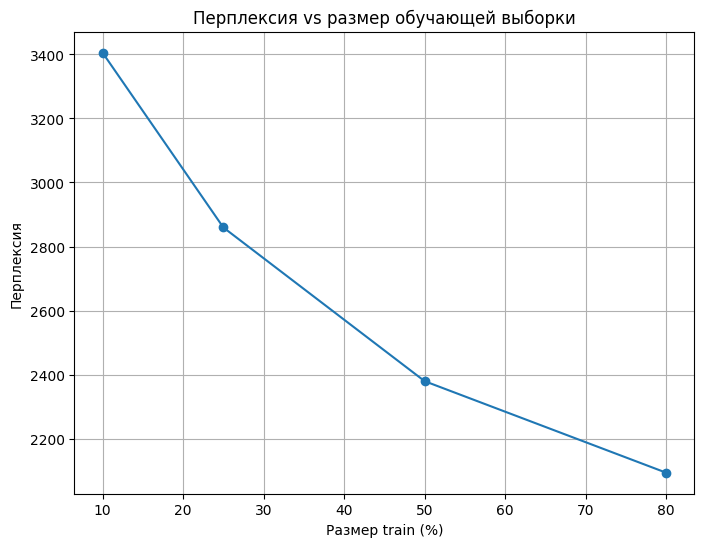

In [21]:


# =========================================================
# График
# =========================================================

plt.figure(figsize=(8, 6))

plt.plot(
    [x * 100 for x in train_sizes],
    perplexities,
    marker="o"
)

plt.title("Перплексия vs размер обучающей выборки")

plt.xlabel("Размер train (%)")
plt.ylabel("Перплексия")

plt.grid(True)

plt.show()


### Вывод: перплексия vs размер обучающей выборки

При **фиксированном** test (последние 20% корпуса) и **фиксированном** размере словаря $V$ перплексия **снижается** при росте train (например, с ~3500 при 10% до ~2180 при 80%).

**Почему фиксируем $V$:** если брать $V$ только из train, при маленьком train словарь занижен — сглаживание Laplace «размазывает» вероятность сильнее, перплексия **искусственно занижается**. Единый $V$ по всему корпусу делает сравнение долей train корректным.

**Что происходит при увеличении данных:**
- модель чаще видела биграммы из теста;
- точнее оценки $P(w_n \mid w_{n-1})$;
- ниже перплексия → модель меньше «удивляется» тесту.

При 80% train результат согласуется с основным экспериментом из п. 13 (тот же test, полный train из первых 80% корпуса).
